# Mô hình hóa phân phối xác suất cho next-time prediction

Notebook này không nhằm tối ưu mô hình cuối cùng. Mục tiêu là kiểm tra khả năng dự đoán của các baseline thống kê và mô hình phân loại nhẹ đối với phân phối xác suất của time bucket tiếp theo. Do phân phối target bị lệch mạnh về các khoảng thời gian ngắn, notebook cần đánh giá cả classification metrics, probability distribution metrics và ordinal/time-aware metrics.

Bài toán trong notebook được mô hình hóa như **phân loại xác suất đa lớp trên các time bucket có thứ tự** (*multiclass probabilistic classification over ordered time buckets*). Với mỗi event hiện tại, mô hình trả về vector xác suất chuẩn hóa `P(bucket_1), ..., P(bucket_k)`.

Câu hỏi chính: **model có thật sự học được temporal signal để dự đoán phân phối thời gian tiếp theo không, hay chỉ đang đoán bucket phổ biến nhất?**

## 1. Setup

Phần này thiết lập thư mục output riêng của notebook, định nghĩa thứ tự bucket cố định và import các thư viện cần thiết. Notebook chỉ đọc target sample đã được tạo bởi feasibility notebook; mọi bảng và hình mới đều được ghi vào `outputs/next_time_probability_distribution/`, không overwrite output của feasibility notebook.

In [1]:
from pathlib import Path
import inspect
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, log_loss, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
RANDOM_STATE = 42

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
TARGET_SAMPLE_DIR = PROJECT_ROOT / "outputs" / "next_time_feasibility" / "target_samples"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "next_time_probability_distribution"
FIGURE_DIR = OUTPUT_DIR / "figures"
PROB_SAMPLE_DIR = OUTPUT_DIR / "probability_samples"
for path in [OUTPUT_DIR, FIGURE_DIR, PROB_SAMPLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

REFINED_TIME_BUCKET_ORDER = ["0_10m", "10_30m", "30m_1h", "1_6h", "6_24h", "1_3d", "3_7d", "gt_7d"]
BUCKET_ORDER = REFINED_TIME_BUCKET_ORDER
BUCKET_TO_INDEX = {bucket: idx for idx, bucket in enumerate(BUCKET_ORDER)}
target_bucket_col = "time_bucket_refined"

SAMPLING_CONFIG = {
    "lastfm": {"max_users": 500, "max_events_per_user": 500, "min_events_per_user": 6},
    "retailrocket": {"max_users": 30000, "max_events_per_user": 50, "min_events_per_user": 6},
    "taobao": {"max_users": 10000, "max_events_per_user": 100, "min_events_per_user": 6},
}
SPLIT_CONFIG = {"test_fraction": 0.2, "min_train_events": 3, "min_test_events": 3, "max_test_events": 20}

def sanitize_filename(value: str) -> str:
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9_.-]+", "_", value)
    return value.strip("_") or "unknown"

def save_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")

def save_figure(fig, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

## 2. Load target samples

Notebook ưu tiên đọc các file parquet trong `outputs/next_time_feasibility/target_samples/`. Sau khi đọc, dữ liệu được chuẩn hóa kiểu cột cơ bản, lọc các dòng có `delta_t_seconds` không hợp lệ, rồi sample theo user để tránh một vài user có lịch sử quá dài chi phối toàn bộ thí nghiệm. Sampling giữ nguyên thứ tự thời gian và giữ các event gần nhất của mỗi user.

In [2]:
DATASET_PATTERNS = {
    "lastfm": ["*lastfm*target*.parquet", "*lastfm*.parquet"],
    "retailrocket": ["*retailrocket*target*.parquet", "*retailrocket*.parquet"],
    "taobao": ["*taobao*target*.parquet", "*taobao*.parquet"],
}
REQUIRED_COLUMNS = ["user_id", "item_id", "event_type", "timestamp", "delta_t_seconds"]
OPTIONAL_COLUMNS = ["dataset", "data_scope", "category_id", "next_timestamp", "time_bucket"]

def discover_target_files(target_dir: Path = TARGET_SAMPLE_DIR) -> dict[str, Path]:
    discovered = {}
    if not target_dir.exists():
        print(f"Target sample directory does not exist: {target_dir}")
        return discovered
    for dataset, patterns in DATASET_PATTERNS.items():
        matches = []
        for pattern in patterns:
            matches.extend(sorted(target_dir.glob(pattern)))
        if matches:
            discovered[dataset] = matches[0]
    return discovered

def sample_users_balanced(df: pd.DataFrame, dataset_key: str, config: dict, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    cfg = config.get(dataset_key, {})
    max_users = cfg.get("max_users")
    max_events_per_user = cfg.get("max_events_per_user")
    min_events_per_user = cfg.get("min_events_per_user", 2)
    df = df.sort_values(["user_id", "timestamp"]).copy()
    user_counts = df["user_id"].value_counts()
    eligible_users = user_counts[user_counts >= min_events_per_user].index.to_numpy()
    rng = np.random.default_rng(random_state)
    if max_users is not None and len(eligible_users) > max_users:
        eligible_users = rng.choice(eligible_users, size=max_users, replace=False)
    sampled = df[df["user_id"].isin(eligible_users)].copy()
    if max_events_per_user is not None:
        sampled = sampled.sort_values(["user_id", "timestamp"]).groupby("user_id", group_keys=False).tail(max_events_per_user).copy()
    return sampled.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

def parquet_columns(path: Path) -> list[str]:
    import pyarrow.parquet as pq
    return pq.ParquetFile(path).schema.names

def load_dataset_sample(dataset_key: str, path: Path) -> pd.DataFrame:
    available_cols = parquet_columns(path)
    columns = [col for col in [*REQUIRED_COLUMNS, *OPTIONAL_COLUMNS] if col in available_cols]
    df = pd.read_parquet(path, columns=columns, engine="pyarrow")
    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f"{dataset_key}: missing required columns: {missing}")
    if "dataset" not in df.columns:
        df["dataset"] = dataset_key
    df["dataset_key"] = dataset_key
    df["dataset"] = df["dataset"].astype(str)
    df["user_id"] = df["user_id"].astype(str)
    df["item_id"] = df["item_id"].astype(str)
    df["event_type"] = df["event_type"].fillna("unknown").astype(str)
    df["category_id"] = df["category_id"].fillna("unknown").astype(str) if "category_id" in df.columns else "unknown"
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    if "next_timestamp" in df.columns:
        df["next_timestamp"] = pd.to_datetime(df["next_timestamp"], utc=True, errors="coerce")
    df["delta_t_seconds"] = pd.to_numeric(df["delta_t_seconds"], errors="coerce")
    df = df.dropna(subset=["user_id", "item_id", "event_type", "timestamp", "delta_t_seconds"])
    df = df[df["delta_t_seconds"] > 0].copy()
    return sample_users_balanced(df, dataset_key, SAMPLING_CONFIG)

target_files = discover_target_files()
print("Discovered target files:")
for dataset, path in target_files.items():
    print(f"- {dataset}: {path}")

samples = {}
load_rows = []
for dataset_key, path in target_files.items():
    raw_meta = pd.read_parquet(path, columns=["user_id"], engine="pyarrow")
    df = load_dataset_sample(dataset_key, path)
    samples[dataset_key] = df
    load_rows.append({
        "dataset": dataset_key,
        "source_file": str(path),
        "raw_rows": len(raw_meta),
        "raw_users": raw_meta["user_id"].nunique(),
        "sampled_rows": len(df),
        "sampled_users": df["user_id"].nunique(),
        "min_timestamp": df["timestamp"].min(),
        "max_timestamp": df["timestamp"].max(),
    })
load_sampling_summary_df = pd.DataFrame(load_rows)
save_csv(load_sampling_summary_df, OUTPUT_DIR / "load_sampling_summary.csv")
display(load_sampling_summary_df)

Discovered target files:
- lastfm: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_samples\lastfm_next_time_targets.parquet
- retailrocket: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_samples\retailrocket_next_time_targets.parquet
- taobao: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_samples\taobao_next_time_targets.parquet
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\load_sampling_summary.csv


,dataset,source_file,raw_rows,raw_users,sampled_rows,sampled_users,min_timestamp,max_timestamp
0,lastfm,y:\Recommender-System-Dashboard\outputs\next_t...,19055618,992,239828,500,2005-03-13 14:03:45+00:00,2009-06-19 20:31:06+00:00
1,retailrocket,y:\Recommender-System-Dashboard\outputs\next_t...,1345435,405966,372463,30000,2015-05-03 03:00:54.461000+00:00,2015-09-18 02:51:14.798000+00:00
2,taobao,y:\Recommender-System-Dashboard\outputs\next_t...,5020662,49996,679848,10000,2015-01-01 02:20:49+00:00,2017-12-11 19:46:25+00:00


## 3. Phân phối target sau khi chia nhỏ time bucket

Bucket cũ `0_1h` quá rộng và thường chiếm tỷ lệ áp đảo. Vì vậy notebook tạo target mới `time_bucket_refined`, chia vùng dưới một giờ thành `0_10m`, `10_30m` và `30m_1h`. Việc chia nhỏ này giúp kiểm tra liệu model có phân biệt được các khoảng thời gian ngắn hơn hay chỉ gom mọi trường hợp ngắn vào một lớp lớn.

Dù chia nhỏ bucket, class imbalance vẫn có thể tồn tại. Vì vậy phần này lưu phân phối target, majority bucket, minority count và imbalance ratio để làm nền cho toàn bộ diễn giải metric phía sau.

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\refined_bucket_distribution_lastfm.png


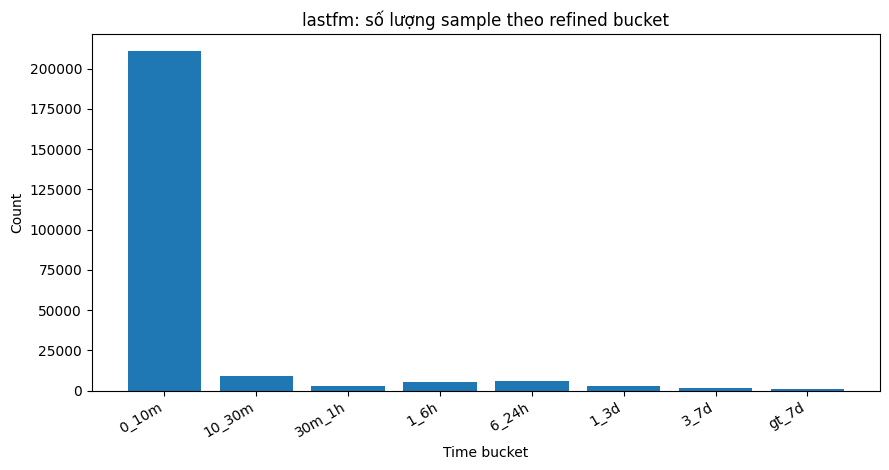

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\refined_bucket_percentage_lastfm.png


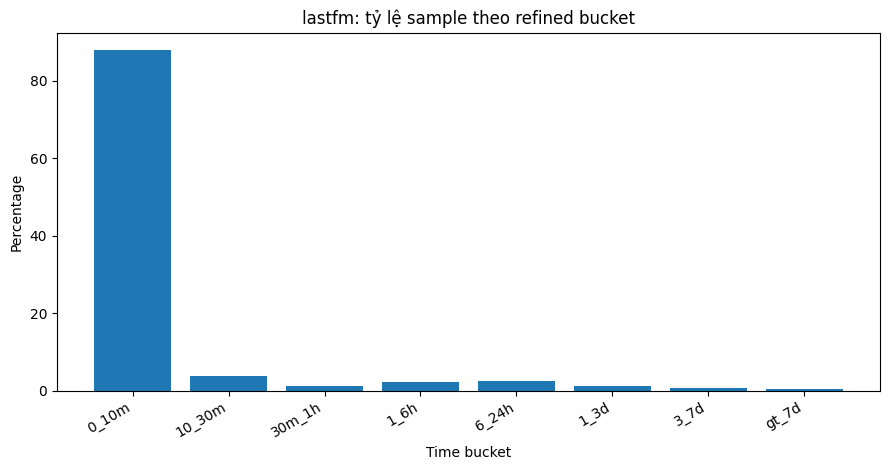

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\probability_samples\lastfm_refined_probability_samples.parquet
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\refined_bucket_distribution_retailrocket.png


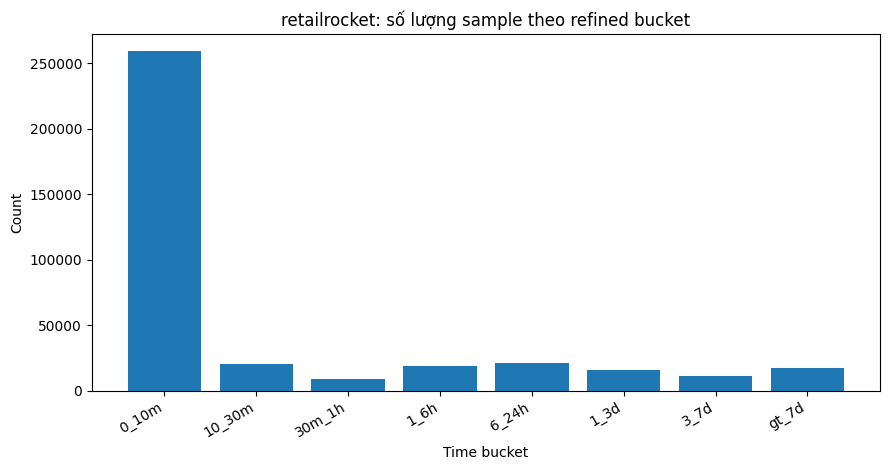

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\refined_bucket_percentage_retailrocket.png


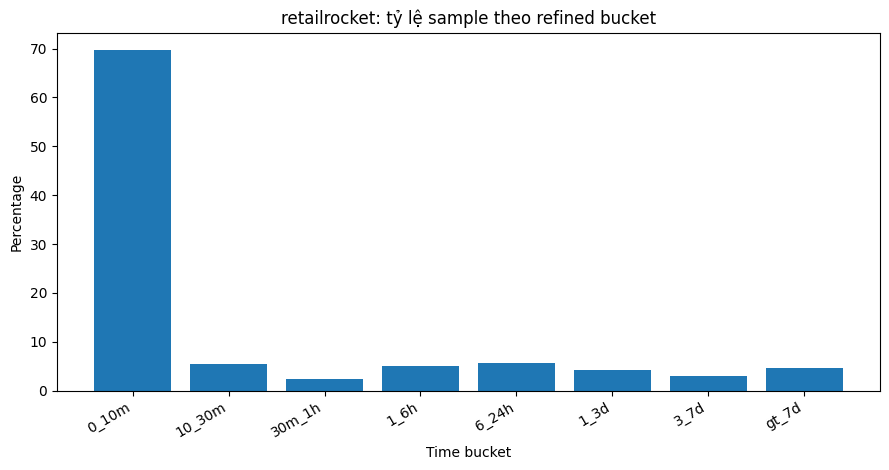

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\probability_samples\retailrocket_refined_probability_samples.parquet
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\refined_bucket_distribution_taobao.png


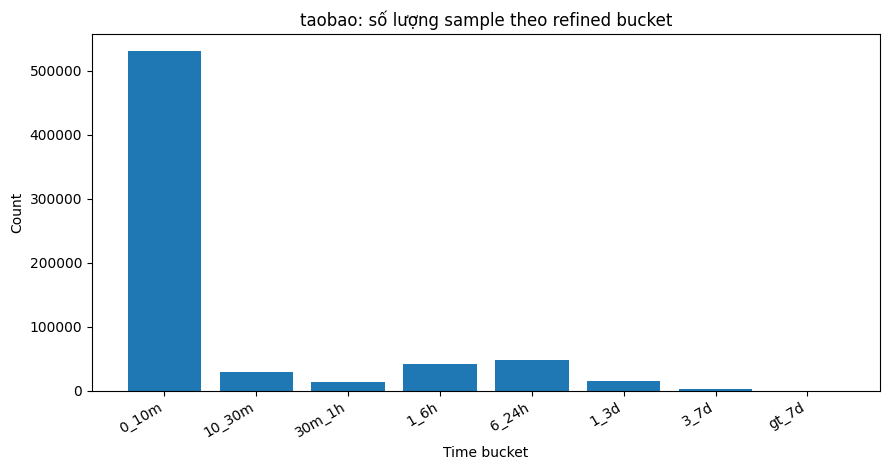

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\refined_bucket_percentage_taobao.png


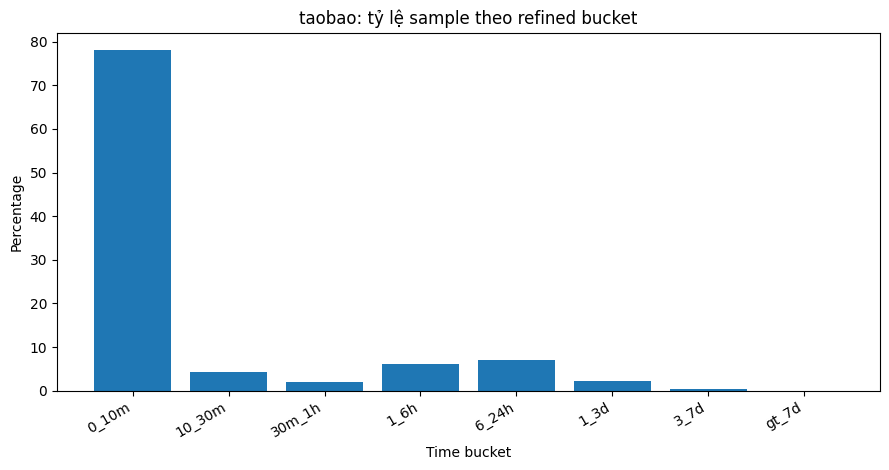

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\probability_samples\taobao_refined_probability_samples.parquet
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\target_refined_bucket_distribution.csv


,dataset,bucket,count,percentage,majority_bucket,majority_bucket_percentage,minority_bucket_count,imbalance_ratio
0,lastfm,0_10m,211045,87.998482,0_10m,87.998482,1257,167.895784
1,lastfm,10_30m,9308,3.881115,0_10m,87.998482,1257,167.895784
2,lastfm,30m_1h,2669,1.112881,0_10m,87.998482,1257,167.895784
3,lastfm,1_6h,5338,2.225762,0_10m,87.998482,1257,167.895784
4,lastfm,6_24h,6001,2.502210,0_10m,87.998482,1257,167.895784
5,lastfm,1_3d,2854,1.190020,0_10m,87.998482,1257,167.895784
6,lastfm,3_7d,1356,0.565405,0_10m,87.998482,1257,167.895784
7,lastfm,gt_7d,1257,0.524126,0_10m,87.998482,1257,167.895784
8,retailrocket,0_10m,259680,69.719677,0_10m,69.719677,8892,29.203779
9,retailrocket,10_30m,20416,5.481350,0_10m,69.719677,8892,29.203779


In [3]:
def assign_refined_time_bucket(delta_t_seconds) -> str | float:
    if pd.isna(delta_t_seconds) or delta_t_seconds <= 0:
        return np.nan
    value = float(delta_t_seconds)
    if value <= 10 * 60:
        return "0_10m"
    if value <= 30 * 60:
        return "10_30m"
    if value <= 60 * 60:
        return "30m_1h"
    if value <= 6 * 60 * 60:
        return "1_6h"
    if value <= 24 * 60 * 60:
        return "6_24h"
    if value <= 3 * 24 * 60 * 60:
        return "1_3d"
    if value <= 7 * 24 * 60 * 60:
        return "3_7d"
    return "gt_7d"

def add_refined_time_bucket(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[target_bucket_col] = df["delta_t_seconds"].map(assign_refined_time_bucket)
    df = df.dropna(subset=[target_bucket_col]).copy()
    df[target_bucket_col] = pd.Categorical(df[target_bucket_col], categories=REFINED_TIME_BUCKET_ORDER, ordered=True)
    return df

probability_samples = {dataset: add_refined_time_bucket(df) for dataset, df in samples.items()}
distribution_rows = []
for dataset, df in probability_samples.items():
    counts = df[target_bucket_col].value_counts(sort=False).reindex(REFINED_TIME_BUCKET_ORDER, fill_value=0)
    total = int(counts.sum())
    nonzero_counts = counts[counts > 0]
    majority_bucket = str(counts.idxmax()) if total else None
    majority_bucket_percentage = float(counts.max() / total * 100) if total else np.nan
    minority_bucket_count = int(nonzero_counts.min()) if len(nonzero_counts) else 0
    imbalance_ratio = float(counts.max() / nonzero_counts.min()) if len(nonzero_counts) else np.nan
    for bucket in REFINED_TIME_BUCKET_ORDER:
        distribution_rows.append({
            "dataset": dataset,
            "bucket": bucket,
            "count": int(counts.loc[bucket]),
            "percentage": float(counts.loc[bucket] / total * 100) if total else 0.0,
            "majority_bucket": majority_bucket,
            "majority_bucket_percentage": majority_bucket_percentage,
            "minority_bucket_count": minority_bucket_count,
            "imbalance_ratio": imbalance_ratio,
        })
    safe_dataset = sanitize_filename(dataset)
    x = np.arange(len(REFINED_TIME_BUCKET_ORDER))
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(x, counts.to_numpy())
    ax.set_xticks(x, REFINED_TIME_BUCKET_ORDER, rotation=30, ha="right")
    ax.set_title(f"{dataset}: số lượng sample theo refined bucket")
    ax.set_xlabel("Time bucket")
    ax.set_ylabel("Count")
    save_figure(fig, FIGURE_DIR / f"refined_bucket_distribution_{safe_dataset}.png")
    plt.show()
    fig, ax = plt.subplots(figsize=(9, 4.8))
    percentages = counts / max(total, 1) * 100
    ax.bar(x, percentages.to_numpy())
    ax.set_xticks(x, REFINED_TIME_BUCKET_ORDER, rotation=30, ha="right")
    ax.set_title(f"{dataset}: tỷ lệ sample theo refined bucket")
    ax.set_xlabel("Time bucket")
    ax.set_ylabel("Percentage")
    save_figure(fig, FIGURE_DIR / f"refined_bucket_percentage_{safe_dataset}.png")
    plt.show()
    sample_path = PROB_SAMPLE_DIR / f"{safe_dataset}_refined_probability_samples.parquet"
    df.to_parquet(sample_path, index=False)
    print(f"Saved: {sample_path}")

target_refined_bucket_distribution_df = pd.DataFrame(distribution_rows)
save_csv(target_refined_bucket_distribution_df, OUTPUT_DIR / "target_refined_bucket_distribution.csv")
display(target_refined_bucket_distribution_df)

## 4. Temporal train/test split

Notebook không dùng random split vì random split có thể đưa thông tin tương lai vào train và làm metric lạc quan giả tạo. Mục tiêu là kiểm tra khả năng dự đoán tương lai từ lịch sử quá khứ, nên mỗi user được sắp xếp theo timestamp; phần đầu chuỗi là train và phần cuối chuỗi là test.

Các feature aggregate hoặc prior distribution đều được fit sau split và chỉ dùng train. Điều này đảm bảo baseline và model không nhìn thấy phân phối bucket của test khi huấn luyện.

In [4]:
def temporal_ratio_split_per_user(
    df: pd.DataFrame,
    user_col: str = "user_id",
    time_col: str = "timestamp",
    test_fraction: float = SPLIT_CONFIG["test_fraction"],
    min_test_events: int = SPLIT_CONFIG["min_test_events"],
    max_test_events: int = SPLIT_CONFIG["max_test_events"],
    min_train_events: int = SPLIT_CONFIG["min_train_events"],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_parts = []
    test_parts = []
    df = df.sort_values([user_col, time_col]).copy()
    for _, group in df.groupby(user_col, sort=False):
        group = group.sort_values(time_col).copy()
        n = len(group)
        if n < min_train_events + min_test_events:
            continue
        test_size = int(np.ceil(n * test_fraction))
        test_size = max(test_size, min_test_events)
        test_size = min(test_size, max_test_events)
        if n - test_size < min_train_events:
            test_size = n - min_train_events
        if test_size <= 0:
            continue
        train_parts.append(group.iloc[:-test_size])
        test_parts.append(group.iloc[-test_size:])
    train_df = pd.concat(train_parts, ignore_index=True) if train_parts else pd.DataFrame(columns=df.columns)
    test_df = pd.concat(test_parts, ignore_index=True) if test_parts else pd.DataFrame(columns=df.columns)
    return train_df, test_df

split_data = {}
split_summary_rows = []
for dataset, df in probability_samples.items():
    train_df, test_df = temporal_ratio_split_per_user(df)
    if train_df.empty or test_df.empty:
        print(f"Skip {dataset}: split produced empty train/test")
        continue
    split_data[dataset] = {"train": train_df, "test": test_df}
    test_users = set(test_df["user_id"].unique())
    train_users = set(train_df["user_id"].unique())
    split_summary_rows.append({
        "dataset": dataset,
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "train_users": train_df["user_id"].nunique(),
        "test_users": test_df["user_id"].nunique(),
        "test_users_seen_in_train_percentage": len(test_users & train_users) / max(len(test_users), 1) * 100,
        "train_min_timestamp": train_df["timestamp"].min(),
        "train_max_timestamp": train_df["timestamp"].max(),
        "test_min_timestamp": test_df["timestamp"].min(),
        "test_max_timestamp": test_df["timestamp"].max(),
    })
temporal_split_summary_df = pd.DataFrame(split_summary_rows)
save_csv(temporal_split_summary_df, OUTPUT_DIR / "temporal_split_summary.csv")
display(temporal_split_summary_df)

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\temporal_split_summary.csv


,dataset,train_rows,test_rows,train_users,test_users,test_users_seen_in_train_percentage,train_min_timestamp,train_max_timestamp,test_min_timestamp,test_max_timestamp
0,lastfm,229924,9904,500,500,100.0,2005-03-13 14:03:45+00:00,2009-06-19 19:02:59+00:00,2005-06-15 12:29:43+00:00,2009-06-19 20:31:06+00:00
1,retailrocket,264685,107778,30000,30000,100.0,2015-05-03 03:00:54.461000+00:00,2015-09-18 02:41:48.782000+00:00,2015-05-03 03:11:46.111000+00:00,2015-09-18 02:51:14.798000+00:00
2,taobao,541144,138704,10000,10000,100.0,2015-01-01 02:20:49+00:00,2017-12-03 15:46:58+00:00,2017-11-24 16:41:34+00:00,2017-12-11 19:46:25+00:00


## 5. Feature engineering không tạo leakage

Các feature dùng cho Logistic Regression chỉ dựa trên event hiện tại hoặc lịch sử trước event hiện tại: loại event, category, giờ trong ngày, thứ trong tuần, số event trước đó và thời gian từ event trước của cùng user/item. Notebook không dùng `next_timestamp`, `next_item_id`, `next_event_type`, `delta_t_seconds`, hoặc target bucket làm feature.

Các prior theo user được tính riêng trong baseline và chỉ fit trên train, sau đó map sang test với fallback global prior nếu user chưa có lịch sử train phù hợp.

In [5]:
BASE_CATEGORICAL_FEATURES = ["event_type", "category_id"]
BASE_NUMERIC_FEATURES = ["hour_of_day", "day_of_week", "is_weekend", "user_event_count_so_far", "item_event_count_so_far", "time_since_user_prev_event", "time_since_item_prev_event"]

def ensure_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values(["timestamp", "user_id", "item_id"])
    df["event_type"] = df["event_type"].fillna("unknown").astype(str)
    df["category_id"] = df["category_id"].fillna("unknown").astype(str)
    df["hour_of_day"] = df["timestamp"].dt.hour.astype(float)
    df["day_of_week"] = df["timestamp"].dt.dayofweek.astype(float)
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df = df.sort_values(["user_id", "timestamp"]).copy()
    df["user_event_count_so_far"] = df.groupby("user_id").cumcount().astype(float)
    prev_user_ts = df.groupby("user_id")["timestamp"].shift(1)
    df["time_since_user_prev_event"] = (df["timestamp"] - prev_user_ts).dt.total_seconds()
    df = df.sort_values(["item_id", "timestamp"]).copy()
    df["item_event_count_so_far"] = df.groupby("item_id").cumcount().astype(float)
    prev_item_ts = df.groupby("item_id")["timestamp"].shift(1)
    df["time_since_item_prev_event"] = (df["timestamp"] - prev_item_ts).dt.total_seconds()
    return df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

prepared_data = {}
for dataset, parts in split_data.items():
    full = pd.concat([parts["train"].assign(_split="train"), parts["test"].assign(_split="test")], ignore_index=True)
    full_with_features = ensure_temporal_features(full)
    train_df = full_with_features[full_with_features["_split"] == "train"].drop(columns="_split").reset_index(drop=True)
    test_df = full_with_features[full_with_features["_split"] == "test"].drop(columns="_split").reset_index(drop=True)
    prepared_data[dataset] = {"train": train_df, "test": test_df}
print({dataset: {"train": len(parts["train"]), "test": len(parts["test"])} for dataset, parts in prepared_data.items()})

{'lastfm': {'train': 229924, 'test': 9904}, 'retailrocket': {'train': 264685, 'test': 107778}, 'taobao': {'train': 541144, 'test': 138704}}


## 6. Baseline thống kê bắt buộc

Notebook dùng ba baseline bắt buộc, tất cả đều trả về `y_pred` và `y_proba` theo đúng thứ tự `REFINED_TIME_BUCKET_ORDER`.

`majority_bucket_classifier` dự đoán mọi sample là majority bucket trong train và gán xác suất 1.0 cho bucket đó. Đây là baseline quan trọng nhất để kiểm tra class imbalance.

`global_prior_distribution` gán cho mọi sample cùng một phân phối prior của train. Đây là baseline phân phối xác suất để so sánh log loss, Brier score và top-k accuracy.

`user_prior_distribution` tính phân phối bucket từ lịch sử train của từng user. Nếu user không có lịch sử trong train, notebook fallback về global prior. Baseline này kiểm tra liệu user có thói quen temporal riêng hay không.

In [6]:
def normalize_probability_matrix(proba: np.ndarray) -> np.ndarray:
    proba = np.asarray(proba, dtype=float)
    proba = np.clip(proba, 0.0, None)
    row_sums = proba.sum(axis=1)
    zero_rows = row_sums <= 0
    if zero_rows.any():
        proba[zero_rows, :] = 1.0 / len(BUCKET_ORDER)
        row_sums = proba.sum(axis=1)
    return proba / row_sums[:, None]

def train_bucket_counts(train_df: pd.DataFrame) -> pd.Series:
    return train_df[target_bucket_col].astype(str).value_counts().reindex(BUCKET_ORDER, fill_value=0)

def global_prior_from_train(train_df: pd.DataFrame) -> np.ndarray:
    counts = train_bucket_counts(train_df).to_numpy(dtype=float)
    return counts / counts.sum() if counts.sum() else np.ones(len(BUCKET_ORDER)) / len(BUCKET_ORDER)

def majority_bucket_classifier(train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    counts = train_bucket_counts(train_df)
    majority_bucket = counts.idxmax()
    y_pred = np.repeat(majority_bucket, len(test_df))
    proba = np.zeros((len(test_df), len(BUCKET_ORDER)), dtype=float)
    proba[:, BUCKET_TO_INDEX[majority_bucket]] = 1.0
    return y_pred, proba

def global_prior_distribution(train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    prior = global_prior_from_train(train_df)
    proba = np.tile(prior, (len(test_df), 1))
    y_pred = np.array(BUCKET_ORDER, dtype=object)[np.argmax(proba, axis=1)]
    return y_pred, proba

def user_prior_distribution(train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    global_prior = global_prior_from_train(train_df)
    counts = train_df.groupby(["user_id", target_bucket_col], observed=False).size().unstack(fill_value=0).reindex(columns=BUCKET_ORDER, fill_value=0)
    lookup = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    proba = np.zeros((len(test_df), len(BUCKET_ORDER)), dtype=float)
    for row_idx, user_id in enumerate(test_df["user_id"].astype(str).to_numpy()):
        if user_id in lookup.index:
            row = lookup.loc[user_id, BUCKET_ORDER].to_numpy(dtype=float)
            proba[row_idx] = row if row.sum() > 0 else global_prior
        else:
            proba[row_idx] = global_prior
    proba = normalize_probability_matrix(proba)
    y_pred = np.array(BUCKET_ORDER, dtype=object)[np.argmax(proba, axis=1)]
    return y_pred, proba

def validate_probability_matrix(proba: np.ndarray, context: str) -> None:
    if proba.ndim != 2 or proba.shape[1] != len(BUCKET_ORDER):
        raise ValueError(f"{context}: expected shape (n, {len(BUCKET_ORDER)}), got {proba.shape}")
    if np.isnan(proba).any() or np.isinf(proba).any():
        raise ValueError(f"{context}: probability matrix contains NaN or inf")
    if (proba < -1e-8).any():
        raise ValueError(f"{context}: probability matrix contains negative values")
    if not np.allclose(proba.sum(axis=1), 1.0, atol=1e-5):
        raise ValueError(f"{context}: probability rows do not sum to 1")

BASELINE_FUNCTIONS = {
    "majority_bucket_classifier": majority_bucket_classifier,
    "global_prior_distribution": global_prior_distribution,
    "user_prior_distribution": user_prior_distribution,
}

## 7. Mô hình phân loại nhẹ

Notebook giữ mô hình đơn giản để kiểm tra feasibility, không thêm deep learning, Transformer, RNN, SASRec, BERT4Rec, survival analysis hay hyperparameter tuning phức tạp.

`logistic_regression` kiểm tra feature hiện tại có chứa linear signal hay không. `logistic_regression_class_weighted` dùng `class_weight="balanced"` để kiểm tra class imbalance có làm mô hình bỏ qua minority buckets không. Class weighting có thể tăng recall/F1 của bucket hiếm, nhưng accuracy hoặc log loss có thể giảm vì model bị ép chú ý hơn đến class hiếm.

In [7]:
def make_one_hot_encoder() -> OneHotEncoder:
    signature = inspect.signature(OneHotEncoder)
    if "sparse_output" in signature.parameters:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, min_frequency=5)
    return OneHotEncoder(handle_unknown="ignore")

def make_preprocessor() -> ColumnTransformer:
    categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", make_one_hot_encoder())])
    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler(with_mean=False))])
    return ColumnTransformer([("categorical", categorical_pipeline, BASE_CATEGORICAL_FEATURES), ("numeric", numeric_pipeline, BASE_NUMERIC_FEATURES)])

def make_logistic_pipeline(class_weight=None) -> Pipeline:
    return Pipeline([
        ("preprocess", make_preprocessor()),
        ("model", LogisticRegression(solver="saga", max_iter=300, n_jobs=-1, random_state=RANDOM_STATE, class_weight=class_weight)),
    ])

def align_model_probabilities(classes, raw_proba: np.ndarray) -> np.ndarray:
    aligned = np.zeros((raw_proba.shape[0], len(BUCKET_ORDER)), dtype=float)
    class_to_idx = {str(cls): idx for idx, cls in enumerate(classes)}
    for target_idx, bucket in enumerate(BUCKET_ORDER):
        if bucket in class_to_idx:
            aligned[:, target_idx] = raw_proba[:, class_to_idx[bucket]]
    return normalize_probability_matrix(aligned)

def train_light_models(train_df: pd.DataFrame) -> dict[str, Pipeline]:
    y_train = train_df[target_bucket_col].astype(str)
    X_train = train_df[BASE_CATEGORICAL_FEATURES + BASE_NUMERIC_FEATURES]
    if y_train.nunique() < 2:
        print("Skip Logistic Regression because train has fewer than 2 classes.")
        return {}
    models = {
        "logistic_regression": make_logistic_pipeline(class_weight=None),
        "logistic_regression_class_weighted": make_logistic_pipeline(class_weight="balanced"),
    }
    fitted = {}
    for model_name, model in models.items():
        print(f"Training {model_name} on {len(train_df):,} rows...")
        model.fit(X_train, y_train)
        fitted[model_name] = model
    return fitted

## 8. Evaluation metrics

Hàm `evaluate_probabilistic_classifier` đánh giá ba nhóm metric. Classification metrics đo top-1 label. Probability distribution metrics đo toàn bộ vector xác suất. Ordinal/time-aware metrics tận dụng thứ tự bucket để phân biệt lỗi gần và lỗi xa.

Trong time bucket classification, dự đoán lệch sang bucket lân cận ít nghiêm trọng hơn dự đoán rất xa. Vì vậy bucket distance là metric quan trọng để đọc cùng accuracy và F1.

In [8]:
def multiclass_brier_score(y_true_idx: np.ndarray, proba: np.ndarray) -> float:
    y_onehot = np.eye(len(BUCKET_ORDER))[y_true_idx]
    return float(np.mean(np.sum((proba - y_onehot) ** 2, axis=1)))

def top_k_accuracy_from_proba(y_true_idx: np.ndarray, proba: np.ndarray, k: int) -> float:
    k = min(k, proba.shape[1])
    top_k = np.argsort(proba, axis=1)[:, -k:]
    return float(np.mean([true_idx in pred_indices for true_idx, pred_indices in zip(y_true_idx, top_k)]))

def evaluate_probabilistic_classifier(y_true, y_pred, y_proba, bucket_order=BUCKET_ORDER) -> dict:
    y_true = pd.Series(y_true).astype(str).to_numpy()
    y_pred = pd.Series(y_pred).astype(str).to_numpy()
    y_true_idx = np.array([BUCKET_TO_INDEX[label] for label in y_true])
    y_pred_idx = np.array([BUCKET_TO_INDEX[label] for label in y_pred])
    distances = np.abs(y_pred_idx - y_true_idx)
    y_proba_safe = normalize_probability_matrix(np.clip(y_proba, 1e-15, 1.0))
    true_label_probs = y_proba_safe[np.arange(len(y_true_idx)), y_true_idx]
    entropy = -np.sum(y_proba_safe * np.log(y_proba_safe), axis=1)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, labels=bucket_order, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, labels=bucket_order, average="weighted", zero_division=0)),
        "log_loss": float(log_loss(y_true, y_proba_safe, labels=bucket_order)),
        "brier_score": multiclass_brier_score(y_true_idx, y_proba_safe),
        "top_2_accuracy": top_k_accuracy_from_proba(y_true_idx, y_proba_safe, 2),
        "top_3_accuracy": top_k_accuracy_from_proba(y_true_idx, y_proba_safe, 3),
        "mean_predicted_confidence": float(np.mean(np.max(y_proba_safe, axis=1))),
        "mean_true_label_probability": float(np.mean(true_label_probs)),
        "mean_entropy": float(np.mean(entropy)),
        "mean_absolute_bucket_distance": float(np.mean(distances)),
        "median_absolute_bucket_distance": float(np.median(distances)),
        "exact_match_rate": float(np.mean(distances == 0)),
        "within_1_bucket_rate": float(np.mean(distances <= 1)),
        "within_2_bucket_rate": float(np.mean(distances <= 2)),
        "far_error_rate": float(np.mean(distances >= 3)),
    }

def per_class_metrics_frame(dataset: str, model: str, y_true, y_pred) -> pd.DataFrame:
    precision, recall, f1, support = precision_recall_fscore_support(pd.Series(y_true).astype(str), pd.Series(y_pred).astype(str), labels=BUCKET_ORDER, zero_division=0)
    return pd.DataFrame({"dataset": dataset, "model": model, "bucket": BUCKET_ORDER, "support": support.astype(int), "precision": precision, "recall": recall, "f1": f1})

def bucket_distance_frame(dataset: str, model: str, y_true, y_pred) -> dict:
    y_true_idx = np.array([BUCKET_TO_INDEX[label] for label in pd.Series(y_true).astype(str)])
    y_pred_idx = np.array([BUCKET_TO_INDEX[label] for label in pd.Series(y_pred).astype(str)])
    distances = np.abs(y_pred_idx - y_true_idx)
    return {"dataset": dataset, "model": model, "distance_0_rate": float(np.mean(distances == 0)), "distance_1_rate": float(np.mean(distances == 1)), "distance_2_rate": float(np.mean(distances == 2)), "distance_ge_3_rate": float(np.mean(distances >= 3)), "mean_absolute_bucket_distance": float(np.mean(distances)), "median_absolute_bucket_distance": float(np.median(distances))}

def make_prediction_frame(dataset: str, model: str, test_df: pd.DataFrame, y_pred, y_proba: np.ndarray) -> pd.DataFrame:
    frame = test_df[["user_id", "item_id", "event_type", "timestamp", target_bucket_col]].copy()
    frame.insert(0, "dataset", dataset)
    frame.insert(1, "model", model)
    frame = frame.rename(columns={target_bucket_col: "true_bucket"})
    frame["predicted_bucket"] = y_pred
    for idx, bucket in enumerate(BUCKET_ORDER):
        frame[f"prob_{bucket}"] = y_proba[:, idx]
    return frame

## 9. Chạy thí nghiệm

Cell này chạy toàn bộ baseline và mô hình nhẹ cho từng dataset. Mỗi model đều sinh `y_pred`, `y_proba`, bảng summary, bảng per-class, bảng bucket distance và sample-level probability output. Probability vector luôn được align theo `REFINED_TIME_BUCKET_ORDER`, kể cả khi train hoặc test thiếu một vài bucket.

In [9]:
classification_rows = []
per_class_frames = []
bucket_distance_rows = []
prediction_frames = []
model_output_store = {}

for dataset, parts in prepared_data.items():
    train_df = parts["train"]
    test_df = parts["test"]
    y_true = test_df[target_bucket_col].astype(str)
    model_output_store[dataset] = {}
    print(f"\n=== {dataset} ===")
    print(f"train={len(train_df):,}, test={len(test_df):,}, train_classes={train_df[target_bucket_col].nunique()}, test_classes={test_df[target_bucket_col].nunique()}")

    for model_name, baseline_fn in BASELINE_FUNCTIONS.items():
        y_pred, y_proba = baseline_fn(train_df, test_df)
        y_proba = normalize_probability_matrix(y_proba)
        validate_probability_matrix(y_proba, f"{dataset}/{model_name}")
        metrics = evaluate_probabilistic_classifier(y_true, y_pred, y_proba, BUCKET_ORDER)
        classification_rows.append({"dataset": dataset, "model": model_name, **metrics})
        per_class_frames.append(per_class_metrics_frame(dataset, model_name, y_true, y_pred))
        bucket_distance_rows.append(bucket_distance_frame(dataset, model_name, y_true, y_pred))
        prediction_frames.append(make_prediction_frame(dataset, model_name, test_df, y_pred, y_proba))
        model_output_store[dataset][model_name] = {"y_pred": np.array(y_pred), "y_proba": y_proba}

    fitted_models = train_light_models(train_df)
    X_test = test_df[BASE_CATEGORICAL_FEATURES + BASE_NUMERIC_FEATURES]
    for model_name, model in fitted_models.items():
        raw_proba = model.predict_proba(X_test)
        y_proba = align_model_probabilities(model.named_steps["model"].classes_, raw_proba)
        validate_probability_matrix(y_proba, f"{dataset}/{model_name}")
        y_pred = np.array(BUCKET_ORDER, dtype=object)[np.argmax(y_proba, axis=1)]
        metrics = evaluate_probabilistic_classifier(y_true, y_pred, y_proba, BUCKET_ORDER)
        classification_rows.append({"dataset": dataset, "model": model_name, **metrics})
        per_class_frames.append(per_class_metrics_frame(dataset, model_name, y_true, y_pred))
        bucket_distance_rows.append(bucket_distance_frame(dataset, model_name, y_true, y_pred))
        prediction_frames.append(make_prediction_frame(dataset, model_name, test_df, y_pred, y_proba))
        model_output_store[dataset][model_name] = {"y_pred": np.array(y_pred), "y_proba": y_proba}

classification_summary_df = pd.DataFrame(classification_rows).sort_values(["dataset", "log_loss", "macro_f1"], ascending=[True, True, False])
per_class_classification_results_df = pd.concat(per_class_frames, ignore_index=True) if per_class_frames else pd.DataFrame()
bucket_error_distance_summary_df = pd.DataFrame(bucket_distance_rows).sort_values(["dataset", "mean_absolute_bucket_distance"])
test_predictions_with_probabilities_df = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()

save_csv(classification_summary_df, OUTPUT_DIR / "classification_summary.csv")
save_csv(per_class_classification_results_df, OUTPUT_DIR / "per_class_classification_results.csv")
save_csv(bucket_error_distance_summary_df, OUTPUT_DIR / "bucket_error_distance_summary.csv")
save_csv(test_predictions_with_probabilities_df, OUTPUT_DIR / "test_predictions_with_probabilities.csv")
display(classification_summary_df)


=== lastfm ===
train=229,924, test=9,904, train_classes=8, test_classes=8
Training logistic_regression on 229,924 rows...
Training logistic_regression_class_weighted on 229,924 rows...

=== retailrocket ===
train=264,685, test=107,778, train_classes=8, test_classes=8
Training logistic_regression on 264,685 rows...
Training logistic_regression_class_weighted on 264,685 rows...

=== taobao ===
train=541,144, test=138,704, train_classes=8, test_classes=8
Training logistic_regression on 541,144 rows...
Training logistic_regression_class_weighted on 541,144 rows...
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\classification_summary.csv
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\per_class_classification_results.csv
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\bucket_error_distance_summary.csv
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\test_p

,dataset,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss,brier_score,top_2_accuracy,top_3_accuracy,mean_predicted_confidence,mean_true_label_probability,mean_entropy,mean_absolute_bucket_distance,median_absolute_bucket_distance,exact_match_rate,within_1_bucket_rate,within_2_bucket_rate,far_error_rate
3,lastfm,logistic_regression,0.833502,0.124970,0.113655,0.758038,0.808293,0.302458,0.875909,0.904786,0.877490,0.735465,5.858417e-01,0.614499,0.0,0.833502,0.876010,0.887217,0.112783
1,lastfm,global_prior_distribution,0.833704,0.125000,0.113664,0.758096,0.819779,0.303256,0.876212,0.904887,0.881978,0.738768,5.659056e-01,0.613086,0.0,0.833704,0.876212,0.887419,0.112581
2,lastfm,user_prior_distribution,0.833704,0.125000,0.113664,0.758096,1.341694,0.296270,0.880149,0.914681,0.880978,0.745254,5.221342e-01,0.613086,0.0,0.833704,0.876212,0.887419,0.112581
4,lastfm,logistic_regression_class_weighted,0.034027,0.116974,0.019115,0.030651,2.179062,0.893637,0.062803,0.217185,0.168119,0.118543,2.058291e+00,5.588045,6.0,0.034027,0.064317,0.154685,0.845315
0,lastfm,majority_bucket_classifier,0.833704,0.125000,0.113664,0.758096,5.743676,0.332593,0.861975,0.873082,1.000000,0.833704,2.488769e-13,0.613086,0.0,0.833704,0.876212,0.887419,0.112581
6,retailrocket,global_prior_distribution,0.640381,0.125000,0.097596,0.499991,1.399604,0.578148,0.695745,0.760044,0.720332,0.476441,1.124096e+00,1.505994,0.0,0.640381,0.695745,0.721325,0.278675
8,retailrocket,logistic_regression,0.639574,0.125150,0.098229,0.500147,1.409897,0.571244,0.713866,0.774648,0.705149,0.473068,1.139221e+00,1.510846,0.0,0.639574,0.694975,0.720667,0.279333
9,retailrocket,logistic_regression_class_weighted,0.146644,0.170232,0.099546,0.167041,2.108839,0.873934,0.245375,0.398978,0.179265,0.131407,2.029372e+00,3.013138,3.0,0.146644,0.253345,0.342222,0.657778
7,retailrocket,user_prior_distribution,0.640140,0.170028,0.175429,0.548564,8.237008,0.570954,0.711546,0.779380,0.757411,0.552461,5.949064e-01,1.367478,0.0,0.640140,0.718857,0.755943,0.244057
5,retailrocket,majority_bucket_classifier,0.640381,0.125000,0.097596,0.499991,12.420795,0.719238,0.708874,0.748631,1.000000,0.640381,2.488769e-13,1.505994,0.0,0.640381,0.695745,0.721325,0.278675


## 10. Phân tích hiệu năng theo từng time bucket

Accuracy cao không đủ nếu recall của bucket hiếm gần bằng 0. Macro-F1 và balanced accuracy phản ánh tốt hơn khả năng học nhiều bucket vì chúng không để majority bucket chi phối toàn bộ kết luận. Nếu model chỉ tốt ở bucket ngắn nhất, kết luận về temporal signal phải thận trọng.

In [10]:
majority_by_dataset = {dataset: train_bucket_counts(parts["train"]).idxmax() for dataset, parts in prepared_data.items()}
minority_bucket_results_df = per_class_classification_results_df.copy()
minority_bucket_results_df["dataset_majority_bucket"] = minority_bucket_results_df["dataset"].map(majority_by_dataset)
minority_bucket_results_df = minority_bucket_results_df[minority_bucket_results_df["bucket"] != minority_bucket_results_df["dataset_majority_bucket"]][["dataset", "model", "bucket", "support", "recall", "f1"]]
save_csv(minority_bucket_results_df, OUTPUT_DIR / "minority_bucket_results.csv")
display(per_class_classification_results_df.sort_values(["dataset", "model", "bucket"]))
display(minority_bucket_results_df.sort_values(["dataset", "model", "bucket"]))

def plot_per_class_metric(dataset: str, model: str, metric: str) -> Path:
    subset = per_class_classification_results_df[(per_class_classification_results_df["dataset"] == dataset) & (per_class_classification_results_df["model"] == model)].set_index("bucket").reindex(BUCKET_ORDER)
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(np.arange(len(BUCKET_ORDER)), subset[metric].fillna(0).to_numpy())
    ax.set_xticks(np.arange(len(BUCKET_ORDER)), BUCKET_ORDER, rotation=30, ha="right")
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{dataset}: per-class {metric} ({model})")
    ax.set_xlabel("Time bucket")
    ax.set_ylabel(metric)
    path = FIGURE_DIR / f"per_class_{metric}_{sanitize_filename(dataset)}_{sanitize_filename(model)}.png"
    save_figure(fig, path)
    plt.show()
    return path

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\minority_bucket_results.csv


,dataset,model,bucket,support,precision,recall,f1
8,lastfm,global_prior_distribution,0_10m,8257,0.833704,1.000000,0.909311
9,lastfm,global_prior_distribution,10_30m,421,0.000000,0.000000,0.000000
13,lastfm,global_prior_distribution,1_3d,175,0.000000,0.000000,0.000000
11,lastfm,global_prior_distribution,1_6h,266,0.000000,0.000000,0.000000
10,lastfm,global_prior_distribution,30m_1h,111,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...
99,taobao,user_prior_distribution,1_6h,9669,0.237037,0.003310,0.006528
98,taobao,user_prior_distribution,30m_1h,2829,0.000000,0.000000,0.000000
102,taobao,user_prior_distribution,3_7d,193,0.000000,0.000000,0.000000
100,taobao,user_prior_distribution,6_24h,10906,0.203125,0.004768,0.009317


,dataset,model,bucket,support,recall,f1
9,lastfm,global_prior_distribution,10_30m,421,0.000000,0.000000
13,lastfm,global_prior_distribution,1_3d,175,0.000000,0.000000
11,lastfm,global_prior_distribution,1_6h,266,0.000000,0.000000
10,lastfm,global_prior_distribution,30m_1h,111,0.000000,0.000000
14,lastfm,global_prior_distribution,3_7d,110,0.000000,0.000000
...,...,...,...,...,...,...
99,taobao,user_prior_distribution,1_6h,9669,0.003310,0.006528
98,taobao,user_prior_distribution,30m_1h,2829,0.000000,0.000000
102,taobao,user_prior_distribution,3_7d,193,0.000000,0.000000
100,taobao,user_prior_distribution,6_24h,10906,0.004768,0.009317


## 11. Phân tích confusion matrix

Confusion matrix cho biết model có bị kéo về bucket phổ biến nhất hay không, các bucket dài như `1_3d`, `3_7d`, `gt_7d` có bị dự đoán nhầm thành bucket ngắn không, và lỗi sai chủ yếu nằm giữa bucket lân cận hay sai rất xa. Best model được chọn theo log loss, sau đó macro-F1 và bucket distance; notebook không chọn best model chỉ theo accuracy.

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\best_model_by_dataset.csv


,dataset,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss,brier_score,top_2_accuracy,top_3_accuracy,mean_predicted_confidence,mean_true_label_probability,mean_entropy,mean_absolute_bucket_distance,median_absolute_bucket_distance,exact_match_rate,within_1_bucket_rate,within_2_bucket_rate,far_error_rate
0,lastfm,logistic_regression,0.833502,0.12497,0.113655,0.758038,0.808293,0.302458,0.875909,0.904786,0.877490,0.735465,0.585842,0.614499,0.0,0.833502,0.876010,0.887217,0.112783
1,retailrocket,global_prior_distribution,0.640381,0.12500,0.097596,0.499991,1.399604,0.578148,0.695745,0.760044,0.720332,0.476441,1.124096,1.505994,0.0,0.640381,0.695745,0.721325,0.278675
2,taobao,global_prior_distribution,0.761038,0.12500,0.108038,0.657770,1.133575,0.407671,0.839666,0.909375,0.786229,0.610608,0.851355,0.739308,0.0,0.761038,0.805456,0.825852,0.174148


Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\confusion_matrix_lastfm_logistic_regression.png


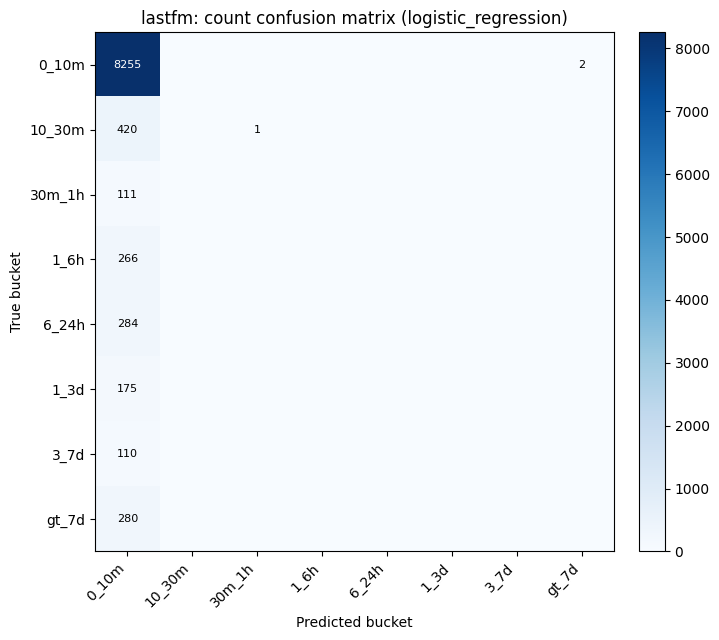

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\confusion_matrix_normalized_lastfm_logistic_regression.png


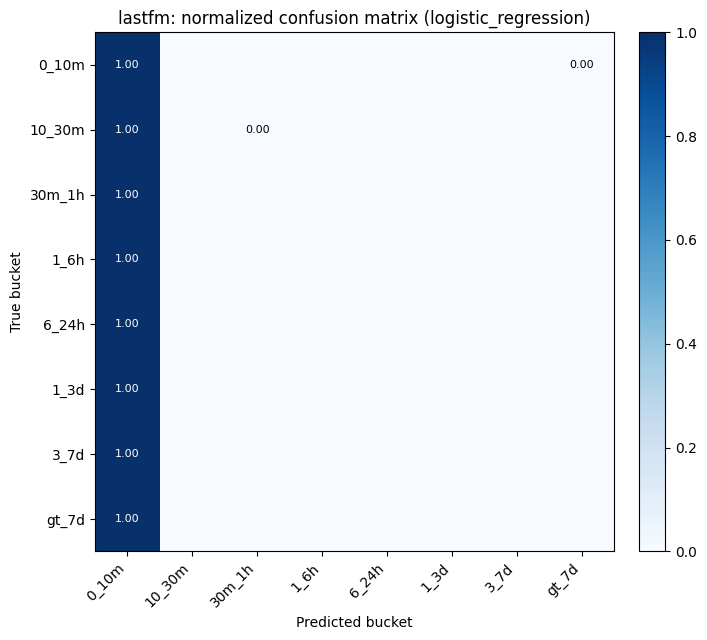

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\per_class_recall_lastfm_logistic_regression.png


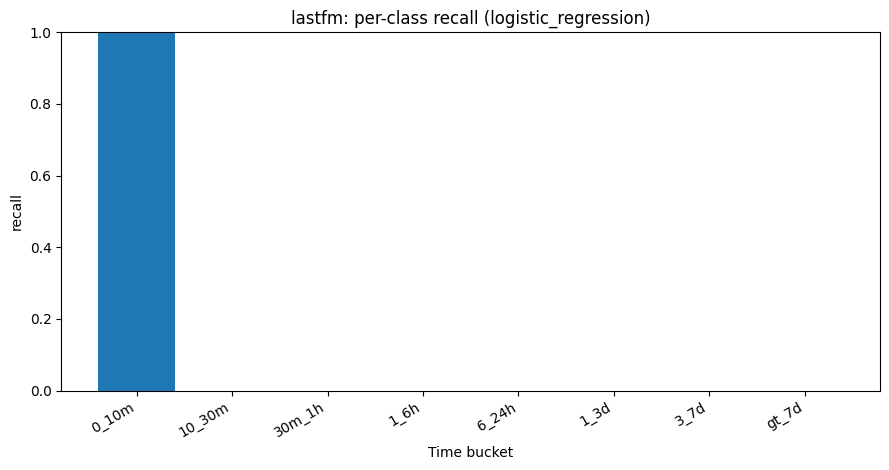

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\per_class_f1_lastfm_logistic_regression.png


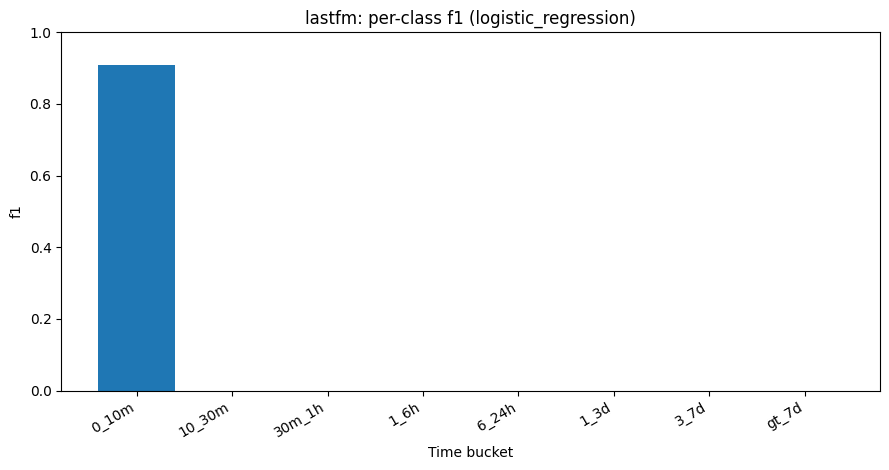

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\confusion_matrix_retailrocket_global_prior_distribution.png


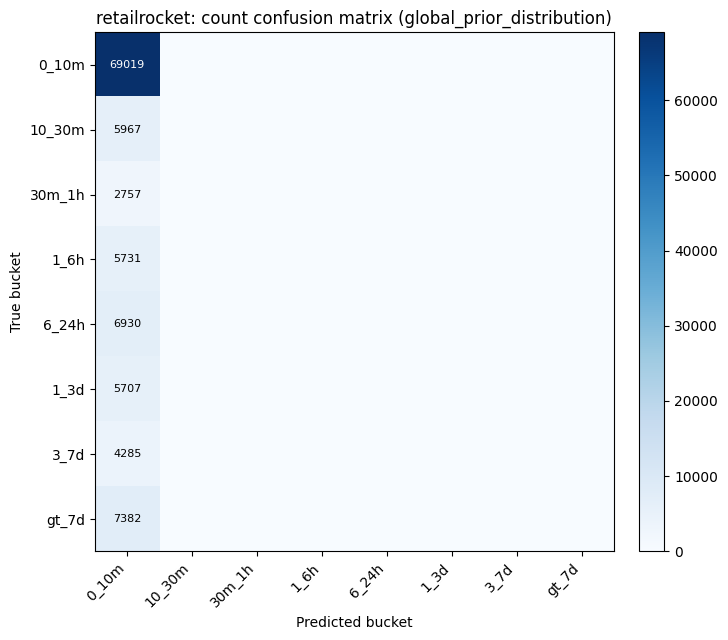

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\confusion_matrix_normalized_retailrocket_global_prior_distribution.png


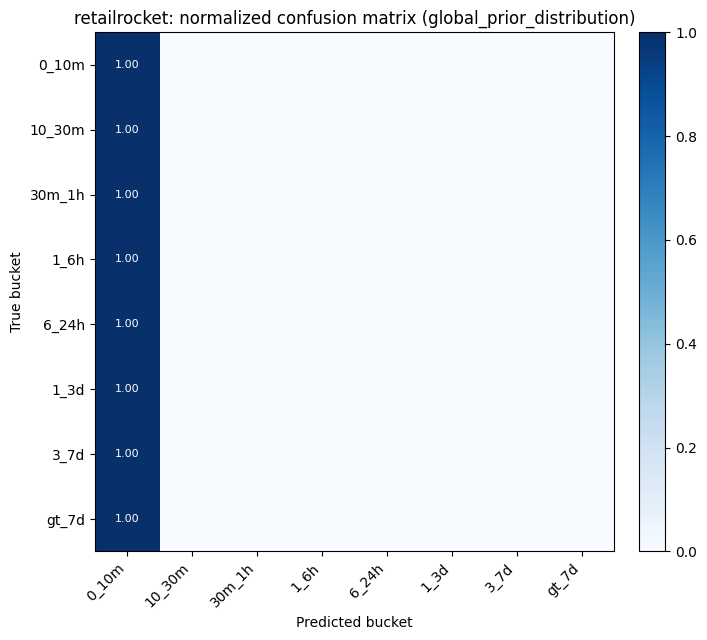

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\per_class_recall_retailrocket_global_prior_distribution.png


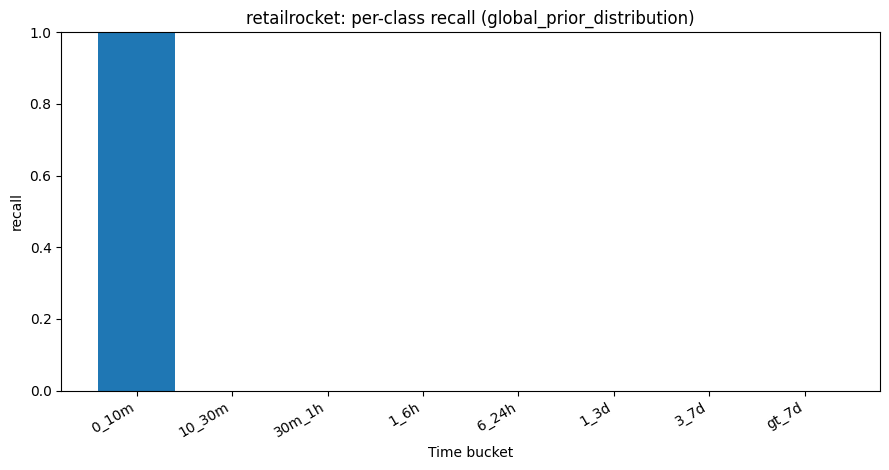

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\per_class_f1_retailrocket_global_prior_distribution.png


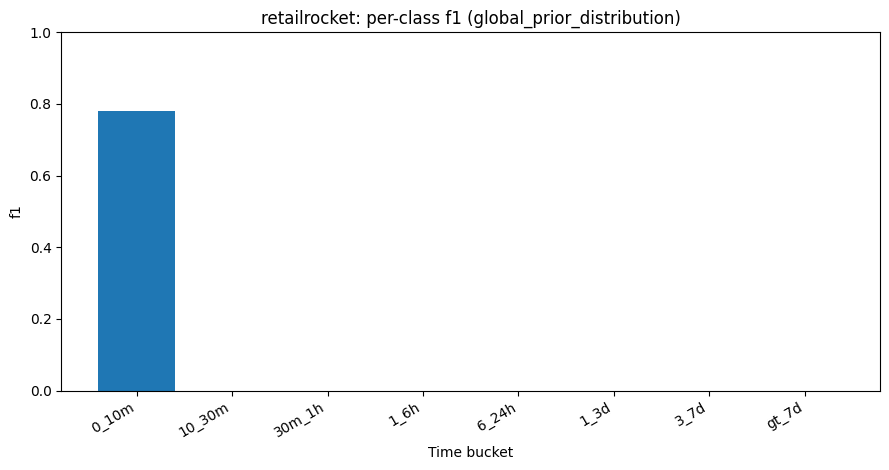

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\confusion_matrix_taobao_global_prior_distribution.png


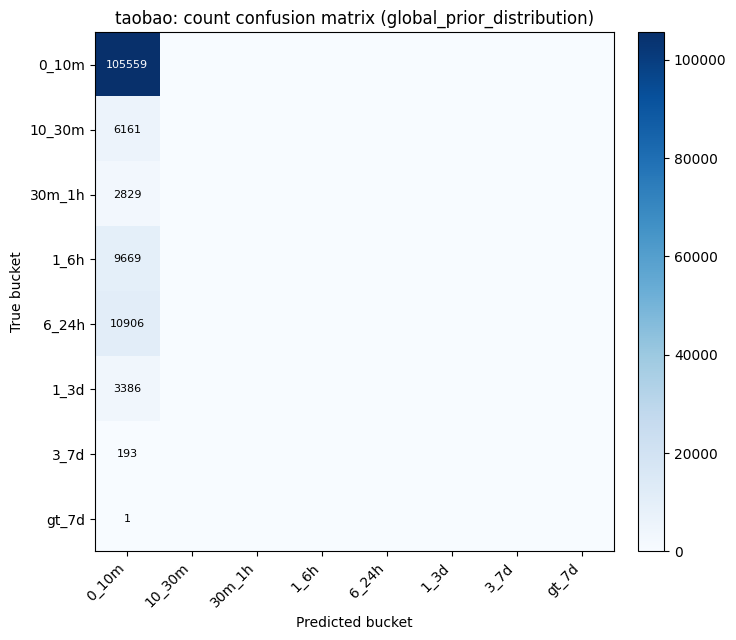

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\confusion_matrix_normalized_taobao_global_prior_distribution.png


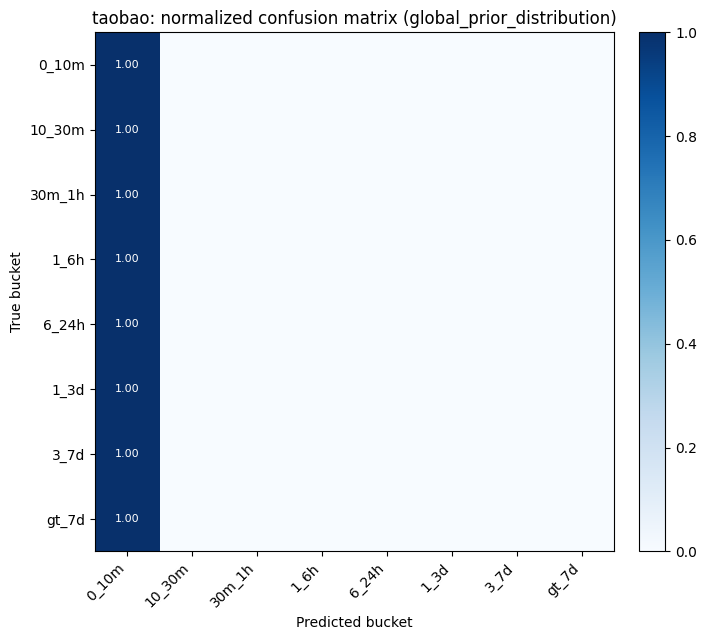

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\per_class_recall_taobao_global_prior_distribution.png


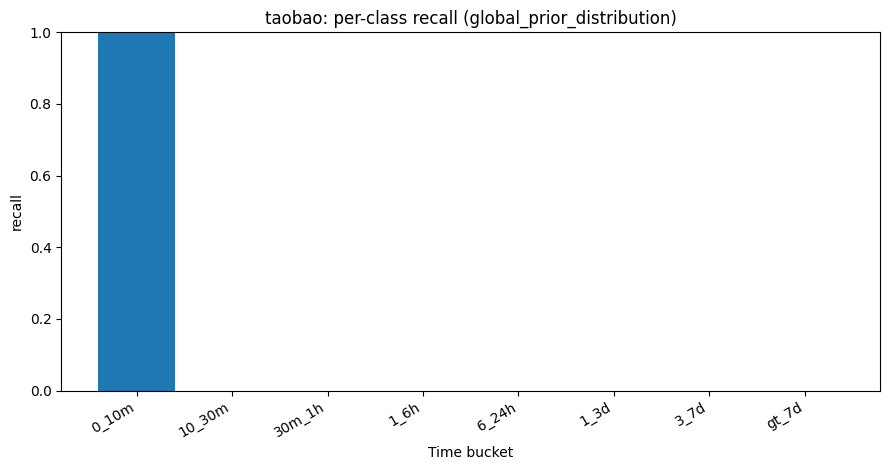

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\per_class_f1_taobao_global_prior_distribution.png


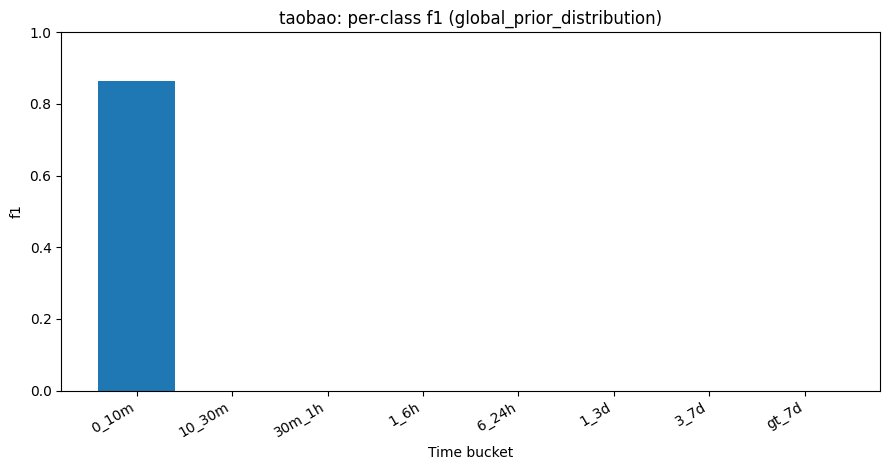

In [11]:
def select_best_model_per_dataset(results_df: pd.DataFrame) -> pd.DataFrame:
    return results_df.sort_values(["dataset", "log_loss", "macro_f1", "mean_absolute_bucket_distance"], ascending=[True, True, False, True]).groupby("dataset", as_index=False).head(1).reset_index(drop=True)

def plot_confusion_matrix(dataset: str, model: str, normalized: bool = False) -> Path:
    y_true = prepared_data[dataset]["test"][target_bucket_col].astype(str).to_numpy()
    y_pred = model_output_store[dataset][model]["y_pred"]
    cm = confusion_matrix(y_true, y_pred, labels=BUCKET_ORDER)
    if normalized:
        denom = cm.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm, denom, out=np.zeros_like(cm, dtype=float), where=denom != 0)
    else:
        cm_plot = cm
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow(cm_plot, cmap="Blues")
    ax.set_xticks(np.arange(len(BUCKET_ORDER)), BUCKET_ORDER, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(BUCKET_ORDER)), BUCKET_ORDER)
    ax.set_xlabel("Predicted bucket")
    ax.set_ylabel("True bucket")
    title_type = "normalized" if normalized else "count"
    ax.set_title(f"{dataset}: {title_type} confusion matrix ({model})")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    threshold = cm_plot.max() / 2 if cm_plot.size else 0
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            value = cm_plot[i, j]
            label = f"{value:.2f}" if normalized and value > 0 else (f"{int(value)}" if (not normalized and value > 0) else "")
            ax.text(j, i, label, ha="center", va="center", color="white" if value > threshold else "black", fontsize=8)
    prefix = "confusion_matrix_normalized" if normalized else "confusion_matrix"
    path = FIGURE_DIR / f"{prefix}_{sanitize_filename(dataset)}_{sanitize_filename(model)}.png"
    save_figure(fig, path)
    plt.show()
    return path

best_model_by_dataset_df = select_best_model_per_dataset(classification_summary_df)
save_csv(best_model_by_dataset_df, OUTPUT_DIR / "best_model_by_dataset.csv")
display(best_model_by_dataset_df)
for _, row in best_model_by_dataset_df.iterrows():
    dataset = row["dataset"]
    model = row["model"]
    plot_confusion_matrix(dataset, model, normalized=False)
    plot_confusion_matrix(dataset, model, normalized=True)
    plot_per_class_metric(dataset, model, "recall")
    plot_per_class_metric(dataset, model, "f1")

## 12. Phân tích khoảng cách lỗi theo thứ tự time bucket

Trong time bucket classification, sai gần bucket thật ít nghiêm trọng hơn sai rất xa. Bucket distance dùng thứ tự cố định của `REFINED_TIME_BUCKET_ORDER` để tính `distance = abs(index(predicted_bucket) - index(true_bucket))`. Metric này giúp đánh giá tốt hơn accuracy khi class có thứ tự.

In [12]:
display(bucket_error_distance_summary_df)

,dataset,model,distance_0_rate,distance_1_rate,distance_2_rate,distance_ge_3_rate,mean_absolute_bucket_distance,median_absolute_bucket_distance
0,lastfm,majority_bucket_classifier,0.833704,0.042508,0.011208,0.112581,0.613086,0.0
1,lastfm,global_prior_distribution,0.833704,0.042508,0.011208,0.112581,0.613086,0.0
2,lastfm,user_prior_distribution,0.833704,0.042508,0.011208,0.112581,0.613086,0.0
3,lastfm,logistic_regression,0.833502,0.042508,0.011208,0.112783,0.614499,0.0
4,lastfm,logistic_regression_class_weighted,0.034027,0.030291,0.090368,0.845315,5.588045,6.0
7,retailrocket,user_prior_distribution,0.640140,0.078717,0.037085,0.244057,1.367478,0.0
5,retailrocket,majority_bucket_classifier,0.640381,0.055364,0.025580,0.278675,1.505994,0.0
6,retailrocket,global_prior_distribution,0.640381,0.055364,0.025580,0.278675,1.505994,0.0
8,retailrocket,logistic_regression,0.639574,0.055401,0.025692,0.279333,1.510846,0.0
9,retailrocket,logistic_regression_class_weighted,0.146644,0.106701,0.088877,0.657778,3.013138,3.0


## 13. Phân tích chất lượng phân phối xác suất dự đoán

Accuracy/F1 chỉ đánh giá bucket top-1. Log loss và Brier score đánh giá toàn bộ probability distribution. Một model có accuracy thấp hơn nhưng log loss tốt hơn vẫn có thể đáng giá hơn nếu mục tiêu là dự đoán phân phối xác suất.

Nếu entropy quá thấp và confidence quá cao, model có thể overconfident. Nếu entropy quá cao, model có thể không phân biệt được bucket. Vì vậy notebook so sánh đồng thời log loss, Brier score, entropy, confidence, true-label probability, top-2 accuracy và top-3 accuracy.

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\probability_metric_comparison.png


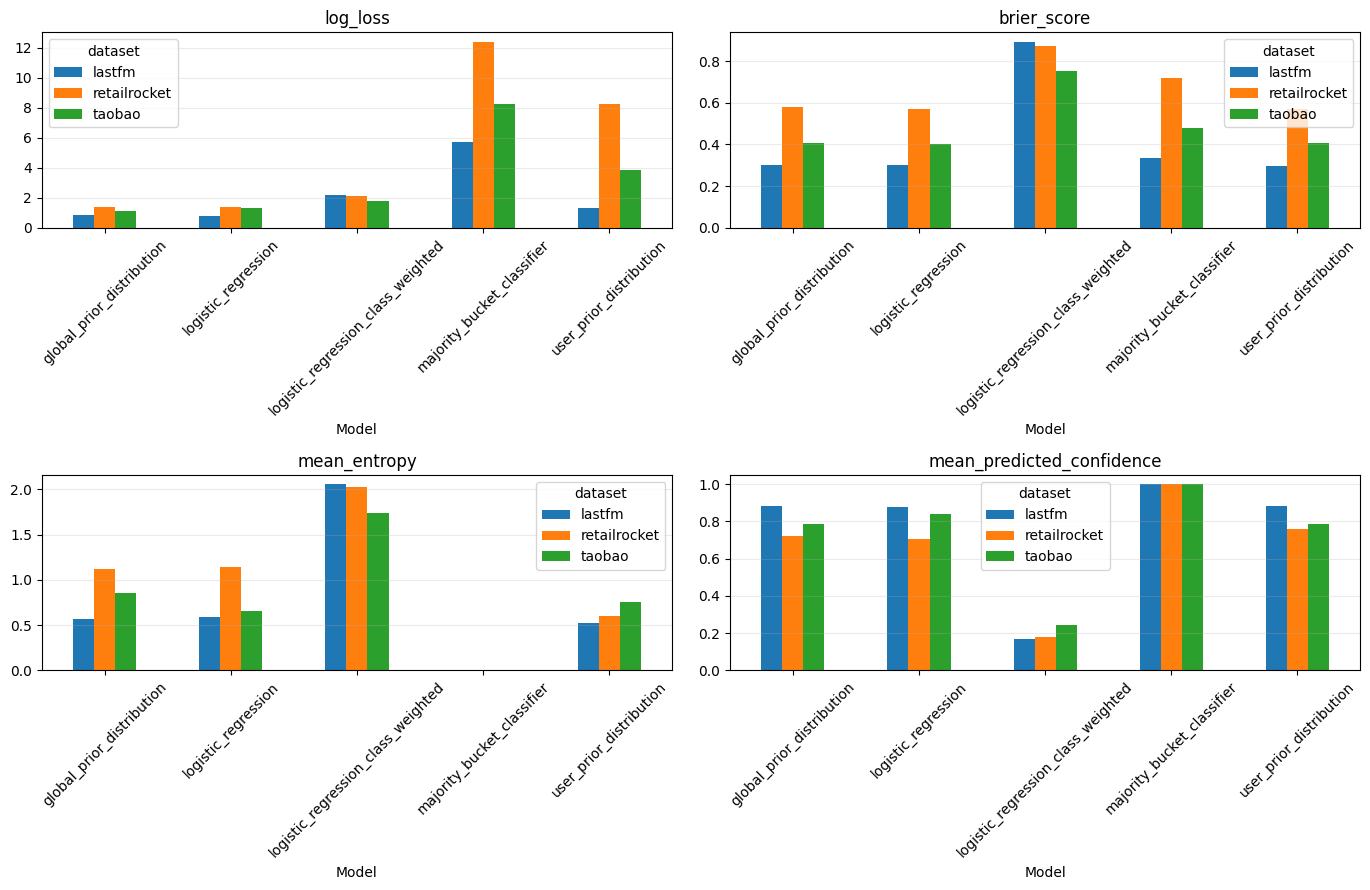

,dataset,model,log_loss,brier_score,mean_entropy,mean_predicted_confidence,mean_true_label_probability,top_2_accuracy,top_3_accuracy
3,lastfm,logistic_regression,0.808293,0.302458,5.858417e-01,0.877490,0.735465,0.875909,0.904786
1,lastfm,global_prior_distribution,0.819779,0.303256,5.659056e-01,0.881978,0.738768,0.876212,0.904887
2,lastfm,user_prior_distribution,1.341694,0.296270,5.221342e-01,0.880978,0.745254,0.880149,0.914681
4,lastfm,logistic_regression_class_weighted,2.179062,0.893637,2.058291e+00,0.168119,0.118543,0.062803,0.217185
0,lastfm,majority_bucket_classifier,5.743676,0.332593,2.488769e-13,1.000000,0.833704,0.861975,0.873082
6,retailrocket,global_prior_distribution,1.399604,0.578148,1.124096e+00,0.720332,0.476441,0.695745,0.760044
8,retailrocket,logistic_regression,1.409897,0.571244,1.139221e+00,0.705149,0.473068,0.713866,0.774648
9,retailrocket,logistic_regression_class_weighted,2.108839,0.873934,2.029372e+00,0.179265,0.131407,0.245375,0.398978
7,retailrocket,user_prior_distribution,8.237008,0.570954,5.949064e-01,0.757411,0.552461,0.711546,0.779380
5,retailrocket,majority_bucket_classifier,12.420795,0.719238,2.488769e-13,1.000000,0.640381,0.708874,0.748631


Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\max_predicted_probability_lastfm.png


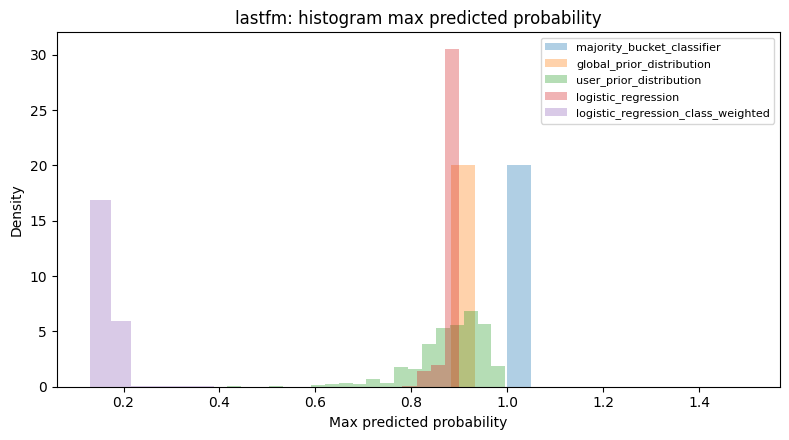

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\max_predicted_probability_retailrocket.png


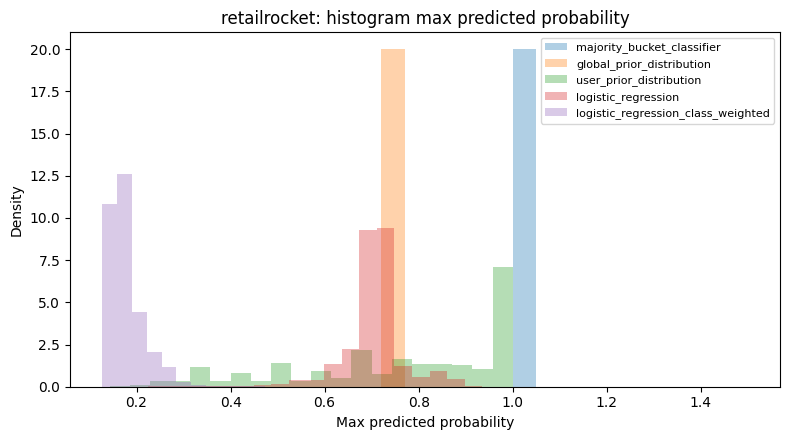

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\max_predicted_probability_taobao.png


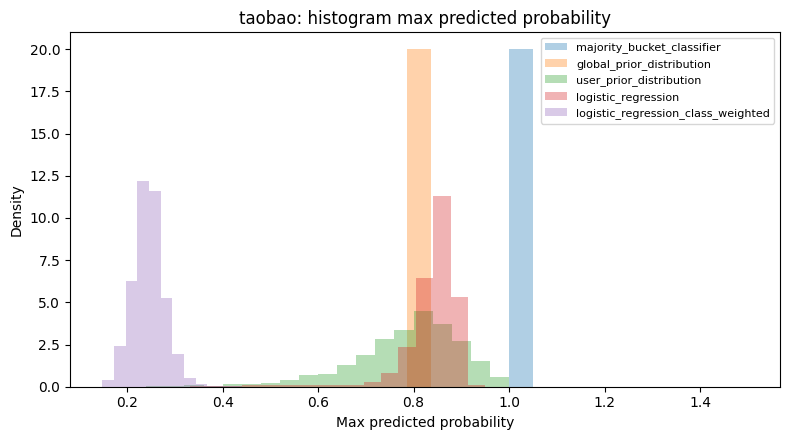

In [13]:
def plot_probability_metric_comparison(results_df: pd.DataFrame) -> Path:
    metrics = ["log_loss", "brier_score", "mean_entropy", "mean_predicted_confidence"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.ravel()
    for ax, metric in zip(axes, metrics):
        pivot = results_df.pivot(index="model", columns="dataset", values=metric)
        pivot.plot(kind="bar", ax=ax)
        ax.set_title(metric)
        ax.set_xlabel("Model")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.25)
    path = FIGURE_DIR / "probability_metric_comparison.png"
    save_figure(fig, path)
    plt.show()
    return path

probability_metric_comparison_path = plot_probability_metric_comparison(classification_summary_df)
probability_metrics_cols = ["dataset", "model", "log_loss", "brier_score", "mean_entropy", "mean_predicted_confidence", "mean_true_label_probability", "top_2_accuracy", "top_3_accuracy"]
display(classification_summary_df[probability_metrics_cols].sort_values(["dataset", "log_loss"]))

for dataset, model_outputs in model_output_store.items():
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for model, outputs in model_outputs.items():
        max_probs = outputs["y_proba"].max(axis=1)
        ax.hist(max_probs, bins=20, alpha=0.35, label=model, density=True)
    ax.set_title(f"{dataset}: histogram max predicted probability")
    ax.set_xlabel("Max predicted probability")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    path = FIGURE_DIR / f"max_predicted_probability_{sanitize_filename(dataset)}.png"
    save_figure(fig, path)
    plt.show()

## 14. Ảnh hưởng của majority bucket

Trong dữ liệu bị lệch mạnh, một mô hình có thể đạt accuracy cao bằng cách dự đoán bucket phổ biến nhất. Vì vậy notebook không dùng accuracy làm bằng chứng duy nhất cho khả năng dự đoán. Các metric như macro-F1, balanced accuracy, log loss, Brier score và bucket distance được dùng để kiểm tra xem model có học được tín hiệu vượt lên trên phân phối prior hay không.

Bảng dưới đây so sánh trực tiếp `majority_bucket_classifier`, `logistic_regression` và `logistic_regression_class_weighted`.

In [14]:
majority_effect_models = ["majority_bucket_classifier", "logistic_regression", "logistic_regression_class_weighted"]
majority_effect_df = classification_summary_df[classification_summary_df["model"].isin(majority_effect_models)].copy()
majority_effect_cols = ["dataset", "model", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "log_loss", "brier_score", "mean_absolute_bucket_distance", "within_1_bucket_rate", "far_error_rate"]
save_csv(majority_effect_df[majority_effect_cols], OUTPUT_DIR / "majority_bucket_effect_comparison.csv")
display(majority_effect_df[majority_effect_cols].sort_values(["dataset", "model"]))

Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\majority_bucket_effect_comparison.csv


,dataset,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss,brier_score,mean_absolute_bucket_distance,within_1_bucket_rate,far_error_rate
3,lastfm,logistic_regression,0.833502,0.124970,0.113655,0.758038,0.808293,0.302458,0.614499,0.876010,0.112783
4,lastfm,logistic_regression_class_weighted,0.034027,0.116974,0.019115,0.030651,2.179062,0.893637,5.588045,0.064317,0.845315
0,lastfm,majority_bucket_classifier,0.833704,0.125000,0.113664,0.758096,5.743676,0.332593,0.613086,0.876212,0.112581
8,retailrocket,logistic_regression,0.639574,0.125150,0.098229,0.500147,1.409897,0.571244,1.510846,0.694975,0.279333
9,retailrocket,logistic_regression_class_weighted,0.146644,0.170232,0.099546,0.167041,2.108839,0.873934,3.013138,0.253345,0.657778
5,retailrocket,majority_bucket_classifier,0.640381,0.125000,0.097596,0.499991,12.420795,0.719238,1.505994,0.695745,0.278675
13,taobao,logistic_regression,0.761060,0.125198,0.108474,0.658064,1.331060,0.402767,0.738731,0.805615,0.173989
14,taobao,logistic_regression_class_weighted,0.567266,0.197135,0.161455,0.601520,1.752331,0.754819,1.152303,0.659267,0.253857
10,taobao,majority_bucket_classifier,0.761038,0.125000,0.108038,0.657770,8.253459,0.477924,0.739308,0.805456,0.174148


## 15. Kết luận

Phần kết luận được sinh từ các bảng kết quả của lần chạy hiện tại để tránh claim quá mạnh. Cần đọc kết luận như một kiểm tra feasibility ban đầu, chưa phải kết quả tối ưu cuối cùng.

In [15]:
def build_conclusion() -> str:
    lines = ["### Kết luận tự động từ lần chạy hiện tại", ""]
    for dataset in sorted(classification_summary_df["dataset"].unique()):
        dist = target_refined_bucket_distribution_df[target_refined_bucket_distribution_df["dataset"] == dataset]
        majority_bucket = dist.iloc[0]["majority_bucket"]
        majority_pct = dist.iloc[0]["majority_bucket_percentage"]
        imbalance_ratio = dist.iloc[0]["imbalance_ratio"]
        subset = classification_summary_df[classification_summary_df["dataset"] == dataset]
        majority = subset[subset["model"] == "majority_bucket_classifier"].iloc[0]
        global_prior = subset[subset["model"] == "global_prior_distribution"].iloc[0]
        best = subset.sort_values(["log_loss", "macro_f1", "mean_absolute_bucket_distance"], ascending=[True, False, True]).iloc[0]
        lr = subset[subset["model"] == "logistic_regression"]
        lrw = subset[subset["model"] == "logistic_regression_class_weighted"]
        minority = minority_bucket_results_df[minority_bucket_results_df["dataset"] == dataset]
        best_minority = minority[minority["model"] == best["model"]]
        nonzero_minority = best_minority[best_minority["support"] > 0]
        avg_minority_recall = nonzero_minority["recall"].mean() if not nonzero_minority.empty else np.nan
        lines.append(f"**{dataset}**")
        lines.append(f"1. Sau khi chia nhỏ bucket dưới 1 giờ, majority bucket là `{majority_bucket}` với {majority_pct:.2f}% sample; imbalance ratio xấp xỉ {imbalance_ratio:.2f}. Điều này cho thấy mức lệch target vẫn cần được xem là yếu tố trung tâm khi diễn giải metric.")
        lines.append(f"2. Best model theo log loss là `{best['model']}` với log loss {best['log_loss']:.4f}, macro-F1 {best['macro_f1']:.4f} và mean bucket distance {best['mean_absolute_bucket_distance']:.4f}.")
        lines.append(f"3. So với `majority_bucket_classifier`, best model {'cải thiện' if best['balanced_accuracy'] > majority['balanced_accuracy'] else 'chưa cải thiện'} balanced accuracy, {'cải thiện' if best['macro_f1'] > majority['macro_f1'] else 'chưa cải thiện'} macro-F1, và {'cải thiện' if best['mean_absolute_bucket_distance'] < majority['mean_absolute_bucket_distance'] else 'chưa cải thiện'} bucket distance.")
        lines.append(f"4. So với `global_prior_distribution`, best model {'cải thiện' if best['log_loss'] < global_prior['log_loss'] else 'chưa cải thiện'} log loss và {'cải thiện' if best['brier_score'] < global_prior['brier_score'] else 'chưa cải thiện'} Brier score.")
        if not lr.empty and not lrw.empty:
            lr = lr.iloc[0]
            lrw = lrw.iloc[0]
            lines.append(f"5. `logistic_regression_class_weighted` có macro-F1 {lrw['macro_f1']:.4f} so với {lr['macro_f1']:.4f} của Logistic Regression thường; cần đọc cùng log loss vì class weighting có thể làm xác suất kém calibration hơn.")
        if np.isfinite(avg_minority_recall):
            lines.append(f"6. Recall trung bình trên minority buckets của best model là {avg_minority_recall:.4f}; nếu giá trị này thấp, model vẫn chủ yếu học bucket phổ biến thay vì phân biệt tốt các bucket hiếm.")
        lines.append(f"7. Mean absolute bucket distance của best model là {best['mean_absolute_bucket_distance']:.4f} và far error rate là {best['far_error_rate']:.4f}; hai giá trị này cho biết lỗi thường gần hay xa bucket thật.")
        lines.append("")
    lines.append("Nhìn chung, notebook này chỉ cung cấp bằng chứng feasibility ban đầu cho bài toán phân loại xác suất đa lớp trên các time bucket có thứ tự. Nếu các mô hình nhẹ cải thiện nhất quán so với majority/global prior ở log loss, Brier score, macro-F1 và bucket distance, có thể nói dữ liệu hiện tại chứa một phần temporal signal học được. Nếu cải thiện yếu hoặc chỉ tốt ở accuracy, kết luận cần thận trọng: mô hình có thể vẫn đang khai thác prior của bucket phổ biến nhất. Notebook này chưa tối ưu mô hình cuối cùng, chưa tuning sâu và chưa xử lý calibration/imbalance ở mức đầy đủ.")
    return "\n".join(lines)

conclusion_text = build_conclusion()
display(Markdown(conclusion_text))

### Kết luận tự động từ lần chạy hiện tại

**lastfm**
1. Sau khi chia nhỏ bucket dưới 1 giờ, majority bucket là `0_10m` với 88.00% sample; imbalance ratio xấp xỉ 167.90. Điều này cho thấy mức lệch target vẫn cần được xem là yếu tố trung tâm khi diễn giải metric.
2. Best model theo log loss là `logistic_regression` với log loss 0.8083, macro-F1 0.1137 và mean bucket distance 0.6145.
3. So với `majority_bucket_classifier`, best model chưa cải thiện balanced accuracy, chưa cải thiện macro-F1, và chưa cải thiện bucket distance.
4. So với `global_prior_distribution`, best model cải thiện log loss và cải thiện Brier score.
5. `logistic_regression_class_weighted` có macro-F1 0.0191 so với 0.1137 của Logistic Regression thường; cần đọc cùng log loss vì class weighting có thể làm xác suất kém calibration hơn.
6. Recall trung bình trên minority buckets của best model là 0.0000; nếu giá trị này thấp, model vẫn chủ yếu học bucket phổ biến thay vì phân biệt tốt các bucket hiếm.
7. Mean absolute bucket distance của best model là 0.6145 và far error rate là 0.1128; hai giá trị này cho biết lỗi thường gần hay xa bucket thật.

**retailrocket**
1. Sau khi chia nhỏ bucket dưới 1 giờ, majority bucket là `0_10m` với 69.72% sample; imbalance ratio xấp xỉ 29.20. Điều này cho thấy mức lệch target vẫn cần được xem là yếu tố trung tâm khi diễn giải metric.
2. Best model theo log loss là `global_prior_distribution` với log loss 1.3996, macro-F1 0.0976 và mean bucket distance 1.5060.
3. So với `majority_bucket_classifier`, best model chưa cải thiện balanced accuracy, chưa cải thiện macro-F1, và chưa cải thiện bucket distance.
4. So với `global_prior_distribution`, best model chưa cải thiện log loss và chưa cải thiện Brier score.
5. `logistic_regression_class_weighted` có macro-F1 0.0995 so với 0.0982 của Logistic Regression thường; cần đọc cùng log loss vì class weighting có thể làm xác suất kém calibration hơn.
6. Recall trung bình trên minority buckets của best model là 0.0000; nếu giá trị này thấp, model vẫn chủ yếu học bucket phổ biến thay vì phân biệt tốt các bucket hiếm.
7. Mean absolute bucket distance của best model là 1.5060 và far error rate là 0.2787; hai giá trị này cho biết lỗi thường gần hay xa bucket thật.

**taobao**
1. Sau khi chia nhỏ bucket dưới 1 giờ, majority bucket là `0_10m` với 78.11% sample; imbalance ratio xấp xỉ 35401.47. Điều này cho thấy mức lệch target vẫn cần được xem là yếu tố trung tâm khi diễn giải metric.
2. Best model theo log loss là `global_prior_distribution` với log loss 1.1336, macro-F1 0.1080 và mean bucket distance 0.7393.
3. So với `majority_bucket_classifier`, best model chưa cải thiện balanced accuracy, chưa cải thiện macro-F1, và chưa cải thiện bucket distance.
4. So với `global_prior_distribution`, best model chưa cải thiện log loss và chưa cải thiện Brier score.
5. `logistic_regression_class_weighted` có macro-F1 0.1615 so với 0.1085 của Logistic Regression thường; cần đọc cùng log loss vì class weighting có thể làm xác suất kém calibration hơn.
6. Recall trung bình trên minority buckets của best model là 0.0000; nếu giá trị này thấp, model vẫn chủ yếu học bucket phổ biến thay vì phân biệt tốt các bucket hiếm.
7. Mean absolute bucket distance của best model là 0.7393 và far error rate là 0.1741; hai giá trị này cho biết lỗi thường gần hay xa bucket thật.

Nhìn chung, notebook này chỉ cung cấp bằng chứng feasibility ban đầu cho bài toán phân loại xác suất đa lớp trên các time bucket có thứ tự. Nếu các mô hình nhẹ cải thiện nhất quán so với majority/global prior ở log loss, Brier score, macro-F1 và bucket distance, có thể nói dữ liệu hiện tại chứa một phần temporal signal học được. Nếu cải thiện yếu hoặc chỉ tốt ở accuracy, kết luận cần thận trọng: mô hình có thể vẫn đang khai thác prior của bucket phổ biến nhất. Notebook này chưa tối ưu mô hình cuối cùng, chưa tuning sâu và chưa xử lý calibration/imbalance ở mức đầy đủ.